# Linear regression

## 1. Load packages and custom functions

In [1]:
# -*- coding: utf-8 -*-
"""
Updated 1 September 2024

"""

from IPython import get_ipython
print(__doc__)

# Clear all the variables
get_ipython().run_line_magic('reset', '-sf')

# suppress all warnings
import warnings
warnings.filterwarnings("ignore")
# from pathlib import Path 
import matplotlib.pyplot as plt
import pandas as pd 
from pathlib import Path 
import os
import sys
import numpy as np
from numpy import mean
import statsmodels.api as sm
import scipy.stats as stats

import seaborn as sns

# scikit-learn (machine learning) package
from sklearn.preprocessing import (StandardScaler)
from sklearn.linear_model import  HuberRegressor

from sklearn.model_selection import RepeatedKFold, permutation_test_score, GroupKFold
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer

# Close all the figures (like in Matlab)
plt.close("all")

# Import configuration file
sys.path.append(str(Path('../src')))
import config as cfg


Updated 1 September 2024




#### Custom functions

In [2]:
def get_var_name(var):
    for name, value in globals().items():
        if value is var:
            return name
        
def groupkfold_regression (
                indices, 
                gt, 
                df, 
                model,
                seed = 1979, 
                verbose=False) :
        """
        Perform a GroupKFold cross-validation on a regression model.

        Parameters
        ----------
        indices : list
            List of indices to use as predictors.
        gt : str
            Name of the column containing the ground truth.
        df : pandas.DataFrame
            Dataframe containing the data.
        model : sklearn.linear_model
            Model to use for the regression.
        seed : int, optional
            Seed for the random number generator. The default is 1979.
        verbose : bool, optional
            Print the results. The default is False.
        
        Returns
        -------
        df_metrics_kfold : pandas.DataFrame
            Dataframe containing the metrics.
        models_list : list
            List of the best models.
        
        """

        # initialize the dataframe to store the metrics
        df_metrics_kfold = pd.DataFrame(columns=[
                                        'INDICE', 
                                        'CCC', 'CCC_L_SHIFT','CCC_S_SHIFT', 'CCC_BIAS', 'MAE', 'RMSE', 'R2', 'MEDIAN_AE', 'pvalue']) 
        
        # empty dictionnary to store the best model for each indice
        models_list = []
        
        # concatenate the list CONFIG['list_indices'] to a string
        INDICE_STR = '_'.join(indices)

        # set a number to each habitat in order to have a unique group for each habitat
        groups = df['habitat'].astype('category').cat.codes
        if verbose : print(f'The groups are {groups.unique()}')  

        # 1. Set the data
        if len(indices) == 1 :
            X_kfold = df[indices].to_numpy().reshape(-1,1)
        else :
            X_kfold = df[indices].to_numpy()
        
        y_kfold = df[gt].to_numpy()

        # 2. Create the kfold cross-validation 
        cv = GroupKFold(n_splits=groups.nunique())

        # 3. Train and test model with repeated cross-validation
        scoring = {
                'MAE': 'neg_mean_absolute_error',
                'MEDIAN_AE': 'neg_median_absolute_error',
                'RMSE': 'neg_root_mean_squared_error',
                'CCC': make_scorer(ccc_est),
                'CCC_L_SHIFT': make_scorer(ccc_l_shift),
                'CCC_S_SHIFT': make_scorer(ccc_s_shift),
                'CCC_BIAS': make_scorer(ccc_bias),
                'R2': 'r2'
                }
        
        # BUG cross_validate does not take CV but rather use the default parameter which is n_splits=5        
        scores = cross_validate(model, 
                                X_kfold, 
                                y_kfold, 
                                scoring=scoring, 
                                cv=cv, 
                                n_jobs=-1, 
                                return_train_score=True, 
                                return_estimator=True,
                                groups=groups)

        # Evaluate the significance of a cross-validated score with permutations.
        # Permutes targets to generate ‘randomized data’ and compute the empirical p-value 
        # against the null hypothesis that features and targets are independent.
        _, _, pvalue = permutation_test_score(
                                model, 
                                X_kfold, 
                                y_kfold, 
                                cv=cv, 
                                n_jobs=-1, 
                                n_permutations=100, 
                                random_state=seed,
                                groups=groups)

        # 5. Metrics
        CCC         = mean(scores['test_CCC'])
        CCC_L_SHIFT = mean(scores['test_CCC_L_SHIFT'])
        CCC_S_SHIFT = mean(scores['test_CCC_S_SHIFT'])
        CCC_BIAS    = mean(scores['test_CCC_BIAS'])
        RMSE        = abs(mean(scores['test_RMSE']))
        MAE         = abs(mean(scores['test_MAE']))
        R2          = mean(scores['test_R2'])
        MEDIAN_AE   = abs(mean(scores['test_MEDIAN_AE']))
        PVALUE      = pvalue
        if verbose :
                print('CCC={} CCC_L_SHIFT={} CCC_S_SHIFT={} CCC_BIAS={} MAE={} RMSE={} R2={} MEDIAN_AE={} P-value={}'.format(
                                                                round(CCC,2),
                                                                round(CCC_L_SHIFT,2),
                                                                round(CCC_S_SHIFT,2),
                                                                round(CCC_BIAS,2), 
                                                                round(MAE,2), 
                                                                round(RMSE,2), 
                                                                round(R2,2),
                                                                round(MEDIAN_AE,2),
                                                                PVALUE))

        # #############################################
        # # Test on datasets that was never seen before
        # #############################################

        # 6. select the best model (median of the scores)
        best_model = scores['estimator'][scores['test_CCC'].argmax()]
        
        # store the best model in a dictionnary corresponding to the current indice
        models_list.append({INDICE_STR: best_model})        

        # 11. Store the scores in a dataframe
        # add the metrics to the dataframe df_metrics
        m = pd.DataFrame.from_dict({
                        'INDICE': [INDICE_STR],
                        'CCC': [CCC],
                        'CCC_L_SHIFT': [CCC_L_SHIFT],
                        'CCC_S_SHIFT': [CCC_S_SHIFT],
                        'CCC_BIAS': [CCC_BIAS],
                        'MAE': [MAE],
                        'RMSE': [RMSE],
                        'R2': [R2],
                        'MEDIAN_AE': [MEDIAN_AE],
                        'pvalue': [PVALUE],
                })
        
        df_metrics_kfold = pd.concat([df_metrics_kfold, m], axis=0, ignore_index=True)

        return df_metrics_kfold, models_list

def plot_datasets (
                y_true, 
                y_pred, 
                metric=None, 
                xlabel="Observation",    
                ylabel="Prediction",
                color=None,
                plot_qqplot=False, 
                plot_residuals=False, 
                plot_residuals_distribution=False):

    """
    Plot the results of a regression model.

    Parameters
    ----------
    y_true : numpy.array
        Observed values.
    y_pred : numpy.array
        Predicted values.
    metric : integer, optional
        Metric to show on the scatter plot. The default is None.
    xlabel : str, optional
        Name of the xlabel. The default is "Species Richness Observed".
    ylabel : str, optional
        Name of the ylabel. The default is None.
    plot_qqplot : bool, optional
        Plot the QQ plot. The default is False.
    plot_residuals : bool, optional
        Plot the residuals. The default is False.
    plot_residuals_distribution : bool, optional
        Plot the residuals distribution. The default is False.
    
    Returns
    -------
    plt
        Plot.
    
    """
    #############################################
    # PLOT observation (y_obs) vs prediction (y_pred)
    #############################################
    fig, ax1 = plt.subplots(1, 1, sharey=True, sharex=True)
    fig.set_size_inches(4,4)
    fig.tight_layout()
    # plot scatter plot
    ax1.scatter(y_true, y_pred, alpha=0.5, color=color)
    ax1.grid()
    # plot the line y=x
    ax1.plot([0, y_true.max()], [0, y_true.max()], 'k--', lw=1)
    # add metric on the plot
    ax1.annotate(
            "%s = %.2f" % (get_var_name(metric), metric), 
            xy=(0.7, 0.05), 
            xycoords='axes fraction', 
            fontsize = 8,
            bbox=dict(
                    facecolor='lightgrey', 
                    alpha = 0.33,
                    edgecolor='white', 
                    boxstyle='round')
            )
    # add x and y labels
    fig.text(0.5, 0, xlabel , ha='center')
    fig.text(0, 0.5, ylabel , va='center', rotation='vertical')
        
    #############################################
    # QQ PLOT
    #############################################
    if plot_qqplot:
        fig, ax3= plt.subplots(1, 1, sharey=True, sharex=True)
        fig.set_size_inches(4,4)
        fig.tight_layout()    
        sm.qqplot(y_true-y_pred, stats.t,  fit=True, alpha=0.25, ax=ax3, markerfacecolor=color, markeredgecolor=color)
        # add the line y=x
        sm.qqline(ax3, line='45', color='k', linewidth=1, linestyle='dashed')
        # add grid
        ax3.grid()

    #############################################       
    # RESIDUALS vs PREDICTION
    ############################################# 
    if plot_residuals:
        fig, ax7 = plt.subplots(1, 1, sharey=True, sharex=True)
        fig.set_size_inches(4,4)
        fig.tight_layout()
        # plot the residuals vs the prediction
        ax7.scatter(y_pred, y_true-y_pred, alpha=0.5, color=color)
        # add the line y=0
        ax7.axhline(y=0, color='k', linestyle='--', linewidth=1)
        # add grid
        ax7.grid()
        # add x and y labels
        fig.text(0.5, 0, "Predicted Values" , ha='center')
        fig.text(0, 0.5, "Residual (Observed - Predicted)", va='center', rotation='vertical')

    #############################################       
    # RESIDUALS DISTRIBUTION
    #############################################
    if plot_residuals_distribution:
        fig, ax5 = plt.subplots(1, 1, sharey=True, sharex=True)
        fig.set_size_inches(4,4)
        fig.tight_layout()
        # plot a histogram of the residuals on axis ax3
        ax5.hist(y_true-y_pred, bins=25, color=color)
        # add grid
        ax5.grid()
        # add x and y labels
        fig.text(0.5, 0, "Residual (Observed - Predicted)" , ha='center')
        fig.text(0, 0.5, "Count", va='center', rotation='vertical')

    return plt


# source : https://rowannicholls.github.io/python/statistics/agreement/concordance_correlation_coefficient.html
def concordance_correlation_coefficient(y_true, y_pred):
    """Concordance correlation coefficient.
    
    (from https://link.springer.com/article/10.1007/s12350-015-0175-7)
    Note that if one of the tests is a reference or “gold standard,” then the bias is based on the difference 
    between the new test’s result and the “true value” of the quantity being measured, 
    and hence a measure of accuracy.10 
    For these cases, the CCC can be said to measure accuracy as well as consistency. 
    But when neither test is a gold standard, it is not appropriate to state that CCC also provides a measure of accuracy.
    
    Parameters
    ----------
    y_true : array-like
        True values.
    y_pred : array-like
        Predicted values.

    """
    # initialize df
    df = pd.DataFrame({
            'y_true': y_true,
            'y_pred': y_pred
            })
    # Remove NaNs
    df = df.dropna()
    # Pearson product-moment correlation coefficients
    y_true = df['y_true']
    y_pred = df['y_pred']
    cor = np.corrcoef(y_true, y_pred)[0][1]
    # Means
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    # Population variances
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    # Population standard deviations
    sd_true = np.std(y_true)
    sd_pred = np.std(y_pred)
    # Calculate CCC
    numerator = 2 * cor * sd_true * sd_pred
    denominator = var_true + var_pred + (mean_true - mean_pred)**2

    return numerator / denominator


def epi_ccc(x, y, ci="z-transform", conf_level=0.95):
    """
    Calculate the concordance correlation coefficient (CCC) and associated statistics.

    -- Source: https://rdrr.io/cran/epiR/man/epi.ccc.html 
    -- Reference: Lawrence, I., & Lin, K. (1989). A concordance correlation coefficient to evaluate reproducibility. habitattrics, 255–268.

    Parameters
    ----------
    x : array-like
        First set of measurements.
    y : array-like
        Second set of measurements.
    ci : str, optional
        Method for confidence interval calculation. Options are "z-transform" (default) or "asymptotic".
    conf_level : float, optional
        Confidence level for the interval. Default is 0.95.
    Returns
    -------
    dict
        A dictionary containing the following keys:
        - "rho_c": dict with keys "est", "lower", and "upper" representing the estimated CCC and its confidence interval.
        - "s_shift": Scale shift.
        - "l_shift": Location shift relative to the scale.
        - "C_b": Bias correction factor.
        - "blalt": Bland-Altman statistics.
        - "nmissing": Number of missing values removed from the input data.
    The function removes any missing values from the input data before performing calculations.
    """

    N = 1 - ((1 - conf_level) / 2)
    zv = stats.norm.ppf(N)

    x = np.array(x)
    y = np.array(y)

    # Remove missing values
    mask = ~np.isnan(x) & ~np.isnan(y)
    x = x[mask]
    y = y[mask]
    nmissing = np.sum(~mask)

    k = len(y)
    yb = np.mean(y)
    sy2 = np.var(y, ddof=1) * (k - 1) / k
    sd1 = np.std(y, ddof=1)

    xb = np.mean(x)
    sx2 = np.var(x, ddof=1) * (k - 1) / k
    sd2 = np.std(x, ddof=1)

    r = np.corrcoef(x, y)[0, 1]
    sl = r * sd1 / sd2

    sxy = r * np.sqrt(sx2 * sy2)
    p = 2 * sxy / (sx2 + sy2 + (yb - xb)**2)

    # Bland-Altman:
    delta = x - y
    rmean = np.mean([x, y], axis=0)
    blalt = np.vstack((rmean, delta)).T

    # Scale shift:
    v = sd1 / sd2
    # Location shift relative to the scale:
    u = (yb - xb) / ((sx2 * sy2) ** 0.25)

    # Bias correction factor:
    C_b = p / r

    # Standard error and CI for asymptotic normal approximation:
    sep = np.sqrt(((1 - r**2) * p**2 * (1 - p**2) / r**2 + (2 * p**3 * (1 - p) * u**2 / r) - 0.5 * p**4 * u**4 / r**2) / (k - 2))
    ll = p - (zv * sep)
    ul = p + (zv * sep)

    # Statistic and CI for inverse hyperbolic tangent transform:
    t = np.log((1 + p) / (1 - p)) / 2
    set = sep / (1 - p**2)
    llt = t - (zv * set)
    ult = t + (zv * set)
    llt = (np.exp(2 * llt) - 1) / (np.exp(2 * llt) + 1)
    ult = (np.exp(2 * ult) - 1) / (np.exp(2 * ult) + 1)

    # Concordance correlation coefficient results:
    if ci == "asymptotic":
        rho_c = {"est": p, "lower": ll, "upper": ul}
    elif ci == "z-transform":
        rho_c = {"est": p, "lower": llt, "upper": ult}

    return {
        "rho_c": rho_c,
        "s_shift": v,
        "l_shift": u,
        "C_b": C_b,
        "blalt": blalt,
        "nmissing": nmissing
    }

def ccc_est(x, y) :
    ccc_summary = epi_ccc(x, y)
    return ccc_summary['rho_c']['est']

def ccc_lower(x, y) :
    ccc_summary = epi_ccc(x, y)
    return ccc_summary['rho_c']['lower']

def ccc_upper(x, y) :
    ccc_summary = epi_ccc(x, y)
    return ccc_summary['rho_c']['upper']

def ccc_s_shift(x, y) :
    ccc_summary = epi_ccc(x, y)
    return ccc_summary['s_shift']

def ccc_l_shift(x, y) :
    ccc_summary = epi_ccc(x, y)
    return ccc_summary['l_shift']

def ccc_bias(x, y) :
    ccc_summary = epi_ccc(x, y)
    return ccc_summary['C_b']


def bland_altman_analysis(df):
    """
    Calculate agreement statistics.

    Within-subject SD and repeatability coefficient are defined in Shukla-Dave
    (2019), available here:
    https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6526078/

    Code from https://rowannicholls.github.io/python/statistics/agreement/bland_altman.html 
    """
    tests = list(df)

    # Individual subject calculations
    df['Means'] = df[tests].mean(axis=1)
    df['Differences'] = df[tests].diff(axis=1)[tests[-1]]
    df['s'] = df[tests].std(axis=1, ddof=1)
    df['var'] = df['s']**2

    # Whole sample calculations
    summary = pd.DataFrame()
    means = ['Mean of ' + test for test in tests]
    for i, mean in enumerate(means):
        summary.loc[1, mean] = df[tests[i]].mean()
    # Sample size
    summary.loc[1, 'Sample Size (n)'] = df.shape[0]
    # Degrees of freedom
    summary.loc[1, 'DOF'] = df.shape[0] - 1
    # Bias (mean difference)
    mean_diff = df['Differences'].mean()
    summary.loc[1, 'Bias'] = mean_diff
    # Sample standard deviations of the differences
    s_diff = df['Differences'].std(ddof=1)
    summary.loc[1, 'Sample SD (s)'] = s_diff
    summary.loc[1, 'Lower LOA'] = mean_diff - 1.96 * s_diff
    summary.loc[1, 'Upper LOA'] = mean_diff + 1.96 * s_diff
    # Within-subject standard deviation
    s_w = np.sqrt(df['var'].mean())
    summary.loc[1, 'Within-Subject SD (Sw)'] = s_w
    # Coefficient of repeatability
    col = 'Repeatability Coefficient (RC)'
    summary.loc[1, col] = np.sqrt(2) * 1.96 * s_w

    # Return
    return df, summary

# from https://stackoverflow.com/questions/27164114/show-confidence-limits-and-prediction-limits-in-scatter-plot
def plot_pi_ci_manual(t, std_error, n, x, x2, y2, ci=True, pi=True, ax=None):
    """Return an axes of confidence bands using a simple approach.

    Notes
    -----
    .. math:: \left| \: \hat{\mu}_{y|x0} - \mu_{y|x0} \: \right| \; \leq \; T_{n-2}^{.975} \; \hat{\sigma} \; \sqrt{\frac{1}{n}+\frac{(x_0-\bar{x})^2}{\sum_{i=1}^n{(x_i-\bar{x})^2}}}
    .. math:: \hat{\sigma} = \sqrt{\sum_{i=1}^n{\frac{(y_i-\hat{y})^2}{n-2}}}

    References
    ----------
    .. [1] M. Duarte.  "Curve fitting," Jupyter Notebook.
        http://nbviewer.ipython.org/github/demotu/BMC/blob/master/notebooks/CurveFitting.ipynb

    """
    if ax is None:
        ax = plt.gca()

    # Confidence Interval (CI)
    if ci:
        ci = t * std_error * np.sqrt(1/n + (x2 - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
        ax.fill_between(x2, y2 + ci, y2 - ci, color="0.25", edgecolor=None, alpha=0.33)

        
    # Prediction Interval (PI)
    if pi:
        pi = t * std_error * np.sqrt(1 + 1/n + (x2 - np.mean(x))**2 / np.sum((x - np.mean(x))**2))   
        ax.fill_between(x2, y2 + pi, y2 - pi, color="None", linestyle="--", linewidth=1)
        ax.plot(x2, y2 - pi, "--", color="0.5", label="95% Prediction Limits", linewidth=1)
        ax.plot(x2, y2 + pi, "--", color="0.5", linewidth=1)

    return ax, ci, pi


## 2. Notebook init and options setting

* Select the annotation file
* Select the dataset to analyze

In [3]:
"""****************************************************************************
# -------------------          options              ---------------------------
****************************************************************************"""
SAVE = True
PROCESS = True
DISPLAY = True
VERBOSE = False
CONFIG = cfg.load_config('config_publication.yaml')

GT = CONFIG['ground_truth']

LIST_INDICES_MULTI_REG= CONFIG['list_indices_multiple_regression']

PALETTE_NAME = "Set2" # Set1 Set2 husl
NUM_COLORS = 7

# set a dictionnary with the color for each habitat
habitat_COLOR = {
        'Arable land': sns.color_palette(PALETTE_NAME, NUM_COLORS)[0],
        'Forest - Subtropical-tropical moist lowland': sns.color_palette(PALETTE_NAME, NUM_COLORS)[1],
        'Forest - Subtropical-tropical moist montane': sns.color_palette(PALETTE_NAME, NUM_COLORS)[2],
        'Plantations': sns.color_palette(PALETTE_NAME, NUM_COLORS)[3],
        'Forest - Temperate': sns.color_palette(PALETTE_NAME, NUM_COLORS)[4],
        'Shrubland - Subtropical-tropical high altitude': sns.color_palette(PALETTE_NAME, NUM_COLORS)[5],
        'Shrubland - Temperate': sns.color_palette(PALETTE_NAME, NUM_COLORS)[6],
            }

# Get the default palette
RED     = sns.color_palette('Set1')[0]
BLUE    = sns.color_palette('Set1')[1]
GREEN   = sns.color_palette('Set1')[2]

## 3. Preparation of the dataframe df

* Open and read dataframes with indices (variables) and with labels (ground truth)
* Clean and merge both dataframes


### 3.1 Clean, merge and save the dataframe with all the data

* Indices where previously calculated with scikit-maad package on Python.
* Manual annotations are coming from different datasets that belong to very different projects. They were formated to be readable in the same way.

> Indices and manual annotations are merged into a single dataframe. Some variables are renamed while others are dropped because we do not want to analyse them. The final dataframe is saved for further analyses, for instance in R.

The number of aggregated samples is 343
The number of sites after removing the habitats with less than 5 aggregated samples is 343


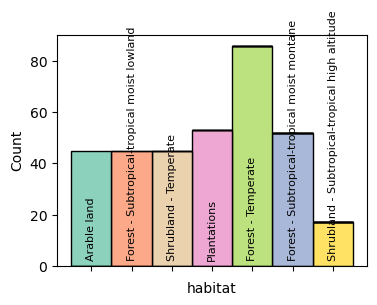

In [4]:
# Read the csv file with the data used for the correlation
df = pd.read_csv(os.path.join(
                            CONFIG['save_dir'], 
                            'species_richness_by_site_and_day.csv'),
                            # 'species_richness_by_site.csv'),
                            # 'species_richness_mean_by_time_month_1h_by_site.csv'),
                            # 'species_richness_mean_by_time_week_15min_by_site.csv'),
                            sep=',')

# print the number of aggregated samples 
print(f'The number of aggregated samples is {df.shape[0]}')

# remove habitat with less than 5 aggregated samples
df = df.groupby('habitat').filter(lambda x: len(x) > 4)

# print the number of sites after removing the habitats with less than 5 aggregated samples
print(f'The number of sites after removing the habitats with less than 5 aggregated samples is {df.shape[0]}')

# plot the density of files for each habitat
fig, ax = plt.subplots(figsize=(4,3))
# display the histogram of the count per habitat and set the legend outside the plot
sns.histplot(df, x='habitat', hue='habitat', multiple='stack', palette=habitat_COLOR, ax=ax, legend=False)
# no xtick label
ax.set_xticklabels([])
# add the habitat in each vertical bar of the histogram
# change the police of the text to 8
for i, v in enumerate(df['habitat'].unique()):
    ax.text(i, 3, str(v), color='black', ha='center', fontsize= 8, rotation=90)

plt.show()


## 4. Regression with linear regression tools



How to interpret negative R² => mostly due to overfitting or problem of domain matching

Link : https://towardsdatascience.com/interpreting-r%C2%B2-a-narrative-guide-for-the-perplexed-086a9a69c1ec 

>  if we constrain ourselves to a narrower set of scenarios, namely linear models, and especially linear models estimated with least squares methods. Here, R² will behave as a proportion. In fact, it can be shown that, due to properties of least squares estimation, a linear model can never do worse than a model predicting the mean of the outcome variable. Which means, that a linear model can never have a negative R² — or at least, it cannot have a negative R² on the same data on which it was estimated (a debatable practice if you are interested in a generalizable model).
> Unrealistically high R² on your training set, or a negative R² on your test set might, respectively, help you entertain the possibility that you might be going for an overly complex model or for an inappropriate modeling approach (e.g., a linear model for non-linear data), or that your outcome variable might contain, mostly, noise.

R² is not a good metric to evaluate a predictive model, especially when the model is not linear and the data is noisy. MAE and RMSE are more informative.

other link : https://towardsdatascience.com/explaining-negative-r-squared-17894ca26321

> Following the above definitions, SS_tot can be calculated using just the data itself, while SS_res depends both on model predictions and the data. While we can use any arbitrary model to generate the predictions for scoring, we need to realize that the aforementioned equality is defined for models trained on the same data. Therefore, it doesn’t necessarily hold true when we use test data to evaluate models built on train data! There is no guarantee that the differences between a foreign model’s predictions and the data is smaller than the variation within the data itself.

> To summarize, we should expect R² to be bounded between zero and one only if a linear regression model is fit, and it is evaluated on the same data it is fitted on. Else, the definition of R² can lead to negative values.

### 4.1 Select and init the regressor

In [5]:
"""****************************************************************************
# -------------------   Regressor  --------------------------
****************************************************************************"""

""" Huber Regressor"""
# https://scikit-learn.org/stable/auto_examples/linear_model/plot_robust_fit.html#sphx-glr-auto-examples-linear-model-plot-robust-fit-py
# Best Regressor when outliers are present in x and y
model = HuberRegressor(max_iter=100, alpha=0.0001, epsilon=1.35, fit_intercept=False, warm_start=False, tol=1e-05)
print('Huber Regressor')


Huber Regressor


### 4.2 With a single indice

In [6]:
#############################################
# Do the kfold regression
#############################################

# Compute the metrics for each indice in order to find the best indice
# remove indices with p value > 0.01

# do not show the error in this cell
warnings.filterwarnings('ignore')

df_metrics_kfold = pd.DataFrame(columns=[
                                'INDICE', 
                                'CCC', 'CCC_L_SHIFT', 'CCC_S_SHIFT', 'CCC_BIAS', 
                                'MAE', 'RMSE', 'R2', 'MEDIAN_AE', 
                                'pvalue'])

best_models_kfolds = {}

# Do Group Kfold Regression
for CURRENT_INDICE in CONFIG['list_indices'] :
    current_df_metrics_kfold, current_model_list = groupkfold_regression(
                                                        indices=[CURRENT_INDICE],
                                                        gt=GT,
                                                        df=df,
                                                        model=model,
                                                        seed = CONFIG['seed'],
                                                        verbose=False, 
                                                        )
    # concatenate the dataframe
    df_metrics_kfold = pd.concat([df_metrics_kfold, current_df_metrics_kfold], axis=0, ignore_index=True) 

    # cadd model to the dictionnary for the current indice
    best_models_kfolds.update(current_model_list[0])

# do not show the error in this cell
warnings.filterwarnings('default')

# sort the dataframe by R_CCC_train
df_metrics_kfold.sort_values(['CCC'], ascending=False, inplace=True)

# remove MAE > 2
df_metrics_kfold_filtered = df_metrics_kfold[df_metrics_kfold['MAE']<5]

# remove pvalue > 0.05
df_metrics_kfold_filtered = df_metrics_kfold_filtered[df_metrics_kfold_filtered['pvalue']<0.05]

# display the dataframe
pd.options.display.float_format = "{:,.2f}".format # display numbers with 2 decimals
display(df_metrics_kfold_filtered)

# interpretation of the scores
# CCC           => CCC is close to 1 when variables are very similar
# CCC_L_SHIFT   => the shift location of equivalent variables is close to 0
# CCC_S_SHIFT   => The scale shift of equivalent variables is close to 1
# CCC_BIAS      => bias correction factor measures the deviation of the regression line of the variables from the line with equation y=x. It is close to 1 when there is no deviation.
# MAE           => MAE close to 0 means no error
# RMSE          => RMSE close to 0 means no error
# R2 
# MEDIAN_AE     => MEDIAN_AE close to 0 means no error
# pvalue

,INDICE,CCC,CCC_L_SHIFT,CCC_S_SHIFT,CCC_BIAS,MAE,RMSE,R2,MEDIAN_AE,pvalue
58,nROI,0.49,-0.26,1.15,0.81,1.02,1.24,-0.77,0.93,0.01
29,EPS,0.34,-0.20,0.87,0.63,1.26,1.47,-1.46,1.12,0.01
27,ECU,0.30,0.43,0.70,0.61,1.42,1.63,-6.13,1.30,0.01
59,aROI,0.29,-1.01,1.20,0.49,1.86,2.11,-3.02,1.94,0.01
28,ECV,0.28,0.53,0.69,0.58,1.54,1.75,-7.77,1.41,0.02
37,BIO,0.28,-0.87,1.02,0.59,1.49,1.73,-2.90,1.42,0.01
0,ZCR,0.20,-0.71,1.12,0.68,1.69,1.98,-5.19,1.56,0.05
42,MFC,0.14,0.15,0.41,0.33,1.37,1.60,-2.08,1.27,0.01
52,H_Renyi,0.14,-0.34,0.83,0.62,1.48,1.74,-2.33,1.34,0.01
39,ADI,0.12,-0.08,0.76,0.35,1.55,1.79,-3.28,1.44,0.01


The coefficient of the best model is [0.00858333]
Statistics=0.988, p=0.006
Known dataset: Residual does not look Gaussian (reject H0)


/tmp/ipykernel_45000/3080284629.py:205: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "%s = %.2f" % (get_var_name(metric), metric),


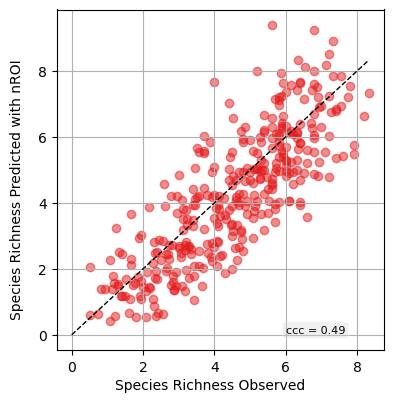

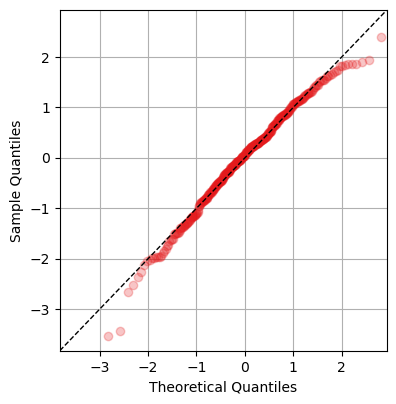

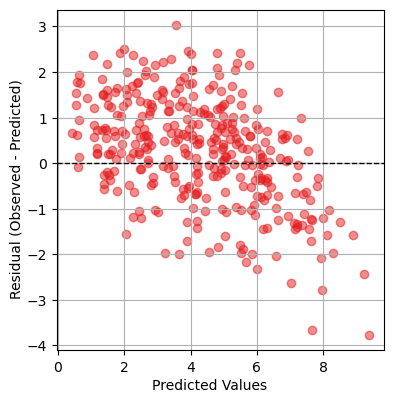

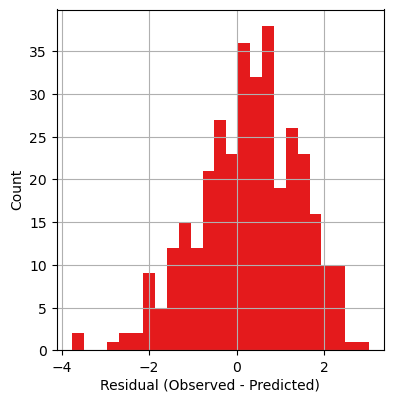

In [7]:
#############################################
# Plot the prediction vs the test
#############################################

INDICE = 'nROI' # nROI ECU EPS

# concatenate the list CONFIG['list_indices'] to a string
INDICE_STR = '_'.join([INDICE])

# with known dataset
X_kfold = df[INDICE].to_numpy().reshape(-1,1)
y_kfold = df[GT].astype('float')

# find the best model corresponding to the indice
best_model = best_models_kfolds[INDICE]

# print the coefficient of the best model
print(f'The coefficient of the best model is {best_model.coef_}')

# do the prediction
y_kfold_pred = best_model.predict(X_kfold)

# extract R_CCC_train from the dataframe (sometimes it's None when the fit is not possible)
ccc = df_metrics_kfold[df_metrics_kfold['INDICE']==INDICE_STR]['CCC']
if len(ccc) == 0 :
        ccc = 0

plot_datasets(
        y_kfold, 
        y_kfold_pred, 
        metric=ccc,
        xlabel='Species Richness Observed',
        ylabel='Species Richness Predicted with '+ ' '.join([INDICE]),
        color=RED,
        plot_qqplot=True,
        plot_residuals=True,
        plot_residuals_distribution=True)

# Test the normality of the residuals with shapiro test
# shapiro test
stat, p = stats.shapiro(y_kfold-y_kfold_pred)
print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
alpha = 0.05
if p > alpha:
        print('Known dataset: Residual looks Gaussian (fail to reject H0)')
else:
        print('Known dataset: Residual does not look Gaussian (reject H0)')


/tmp/ipykernel_45000/1781182020.py:62: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax1.scatter([], [], c=habitat_COLOR[habitat], label=habitat, marker='s', s=40)


prediction interval is  2.355357548350917


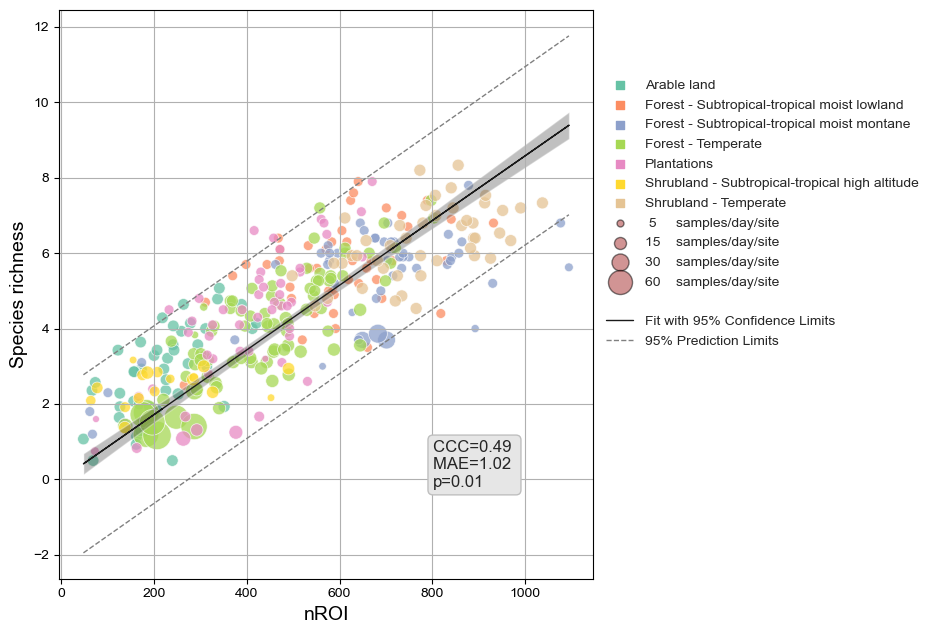

In [8]:
"""----------------------------------------------------------------
      Display correlation between the indice and the ground truth. 
-----------------------------------------------------------------"""

######
# sort the column habitat to have the same automatic color assignation
df = df.sort_values(by='habitat')

# Set the variables
x = df[INDICE].values
y = df[GT].values
y_model = (best_model.coef_[0])*x   

# Statistics
n = df[INDICE].size                                         # number of observations
m = 1                                                       # number of parameters
dof = n - m                                                 # degrees of freedom
t = stats.t.ppf(0.975, dof)                                 # t-statistic; used for CI and PI bands

# Estimates of Error in Data/Model
residual = y - y_model                                      # residuals; diff. actual data from predicted values
chi2     = np.sum((residual / (y_model+0.01))**2)           # chi-squared; estimates error in data
chi2_red = chi2 / dof                                       # reduced chi-squared; measures goodness of fit
S        = np.sqrt(np.sum(residual**2) / dof)               # standard error of the regression S also known as the standard error of the estimate
######

# Display the correlation graphic between the indice and the ground truth
fig, ax1 = plt.subplots(1, 1)
ax1.grid()

# marker size
# extact the column count from df, and multiply the values (scalar) by 5
marker_size = df['count'].values*5

# display the scatterplot
sns.set_theme(style="whitegrid")
sns.set_style("ticks")
sns.scatterplot(data=df, x=INDICE, y=GT, hue='habitat', palette=habitat_COLOR, alpha=0.75, s=marker_size, ax=ax1, legend=False)

# change y axis label
ax1.set_ylabel('Species richness', size=14)

# change x axis label
ax1.set_xlabel(INDICE, size=14)

# add metrics on the graph
ax1.annotate(
      # "CCC=%.2f \nS=%.2f \np<0.01 \ncoef=%.3f "% (df_metrics_kfold[df_metrics_kfold['INDICE']==INDICE]['CCC'].iloc[0], std_error, best_model.coef_[0]), 
      "CCC=%.2f \nMAE=%.2f \np=%.2f" % (df_metrics_kfold[df_metrics_kfold['INDICE']==INDICE]['CCC'].iloc[0], df_metrics_kfold[df_metrics_kfold['INDICE']==INDICE]['MAE'].iloc[0], df_metrics_kfold[df_metrics_kfold['INDICE']==INDICE]['pvalue'].iloc[0]), 
      xy=(0.7, 0.2), 
      xycoords='axes fraction', 
      ha='left', 
      va='center', 
      bbox=dict(
            facecolor="0.9", 
            edgecolor='0.75', 
            boxstyle='round')
      )

# add a legend with fixed marker size for each habitat and its corresponding color
for habitat in df['habitat'].unique():
      ax1.scatter([], [], c=habitat_COLOR[habitat], label=habitat, marker='s', s=40)

# add bubble size legend
bubble_sizes = [5, 15, 30, 60, 0]
bubble_labels = [' 5     samples/day/site', '15    samples/day/site', '30    samples/day/site', '60    samples/day/site', '  ']
for size, label in zip(bubble_sizes, bubble_labels):
      ax1.scatter([], [], c='brown', edgecolor='black', alpha=0.5, s=size*5, label=label)


# plot the line of best fit
ax1.plot(x, y_model, "-", color='0.1', linewidth=1, alpha=1, label="Fit with 95% Confidence Limits")  

# Confidence Interval
x2 = np.linspace(np.min(x), np.max(x), 100)
y2 = (best_model.coef_[0])*x2

# plot the confidence interval and the prediction interval on the graph
_, ci, pi = plot_pi_ci_manual(t, S, n, x, x2, y2, ax=ax1)
print("prediction interval is ", np.mean(pi))

# Move the legend to the bottom
ax1.legend(title="habitat", loc="upper left", fontsize=8)
# sns.move_legend(ax1, "upper center", bbox_to_anchor=(.5, -0.1), ncol=2, title=None, frameon=False, fontsize=8)
sns.move_legend(ax1, "upper left", bbox_to_anchor=(1, 0.9), ncol=1, title=None, frameon=False, fontsize=10)

# Set figure size
fig.set_size_inches((9.5,6.5))
fig.tight_layout()

if INDICE == 'nROI' :
      if SAVE : fig.savefig(os.path.join(CONFIG['save_dir'], 'figure_1c.png'), dpi = 300, bbox_inches = "tight")
if INDICE == 'EPS' :
      if SAVE : fig.savefig(os.path.join(CONFIG['save_dir'], 'figure_S4a.png'), dpi = 300, bbox_inches = "tight")
if INDICE == 'ECU' :
      if SAVE : fig.savefig(os.path.join(CONFIG['save_dir'], 'figure_S4b.png'), dpi = 300, bbox_inches = "tight")

In [9]:
epi_ccc(x*best_model.coef_[0],y,ci="z-transform",conf_level=0.95)

{'rho_c': {'est': 0.8002964415842176,
  'lower': 0.7600255110297786,
  'upper': 0.8344450553373182},
 's_shift': 0.8887100413291735,
 'l_shift': 0.1466770141676317,
 'C_b': 0.9825834203343142,
 'blalt': array([[ 3.08033004, -2.4107685 ],
        [ 1.6862276 , -1.19897337],
        [ 1.81018304, -0.09391963],
        [ 2.55704208, -2.17163013],
        [ 2.50236839, -1.5666918 ],
        [ 2.59177036, -1.2450307 ],
        [ 2.47418209,  1.08169751],
        [ 2.2161804 , -0.10097253],
        [ 3.76808854, -0.46382291],
        [ 1.50857599, -0.83999088],
        [ 2.20727644, -1.44258998],
        [ 2.14695326, -0.42037919],
        [ 2.41487615, -1.02739056],
        [ 2.84707544, -0.30584912],
        [ 3.87694714, -0.53182001],
        [ 3.33599706, -1.32800587],
        [ 3.04997676, -1.04290362],
        [ 1.26906419,  0.2524141 ],
        [ 0.54623437,  0.09246874],
        [ 1.15853099,  0.45991913],
        [ 1.70696122, -0.7289347 ],
        [ 1.72336124, -0.55327752],
      

### 4.3 Regression with multiple indices

In [10]:
#############################################
# Do the kfold regression
#############################################

# do not show the error in this cell
warnings.filterwarnings("ignore")

# Normalize the data as now there are 60 indices
df_scaled = df.copy()
scaler = StandardScaler()
df_scaled[LIST_INDICES_MULTI_REG + [GT]] = scaler.fit_transform(df_scaled[LIST_INDICES_MULTI_REG + [GT]]) 

df_metrics_kfold, models_list = groupkfold_regression(
                                indices=LIST_INDICES_MULTI_REG,
                                gt=GT,
                                df=df_scaled,
                                model=model,
                                seed = CONFIG['seed'],
                                verbose=True,
                            )   

warnings.filterwarnings('default')


The groups are [0 1 2 3 4 5 6]
CCC=0.65 CCC_L_SHIFT=-0.19 CCC_S_SHIFT=1.44 CCC_BIAS=0.84 MAE=0.44 RMSE=0.61 R2=-4.62 MEDIAN_AE=0.34 P-value=0.42574257425742573


In [11]:
#############################################
# display the metrics
#############################################

pd.options.display.float_format = "{:,.2f}".format # display numbers with 2 decimals
df_metrics_kfold.sort_values(['CCC'], ascending=False, inplace=True)   
display(df_metrics_kfold.head(2))

,INDICE,CCC,CCC_L_SHIFT,CCC_S_SHIFT,CCC_BIAS,MAE,RMSE,R2,MEDIAN_AE,pvalue
0,NP_SNRf_ECV_AnthroEnergy_BioEnergy_BIO_LFC_TFS...,0.65,-0.19,1.44,0.84,0.44,0.61,-4.62,0.34,0.43


Statistics=0.996, p=0.483
Known dataset: Residual looks Gaussian (fail to reject H0)


/home/haupert/miniconda3/envs/ear-ml/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but HuberRegressor was fitted without feature names
  warnings.warn(
/tmp/ipykernel_45000/3080284629.py:205: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "%s = %.2f" % (get_var_name(metric), metric),


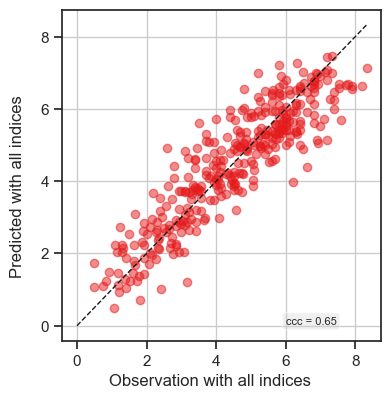

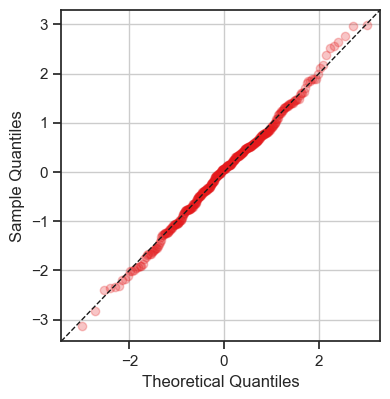

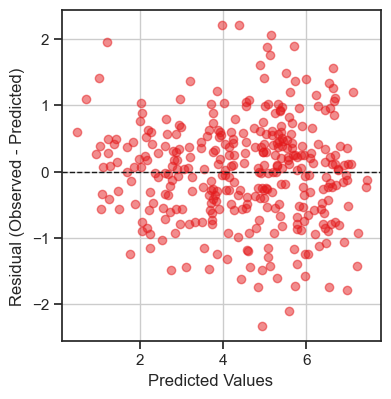

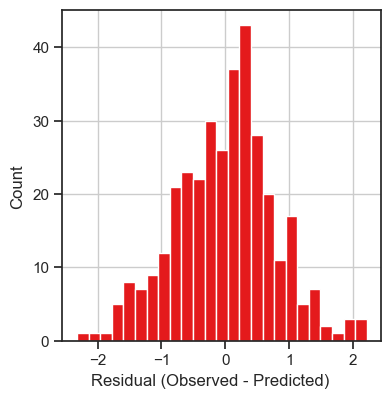

In [12]:
#############################################
# Plot the prediction vs the test
#############################################

# concatenate the list LIST_INDICES_MULTI_REG to a string
INDICE_STR = '_'.join(LIST_INDICES_MULTI_REG)

# with known dataset
X_kfold = df_scaled[LIST_INDICES_MULTI_REG].astype('float')
y_kfold = df_scaled[GT].astype('float')

# find the first value of the dictionnary models_list
best_model = models_list[0]
# get the key of the dictionnary
indice = list(best_model.keys())[0]  
# get the value of the dictionnary
best_model = best_model[indice]

# do the prediction
y_kfold_pred = best_model.predict(X_kfold[LIST_INDICES_MULTI_REG])

# inverse normalize
X_kfold[GT] = y_kfold
y_kfold = scaler.inverse_transform(X_kfold)[:,-1]
X_kfold[GT] = y_kfold_pred
y_kfold_pred = scaler.inverse_transform(X_kfold)[:,-1]

# metric
ccc = df_metrics_kfold[df_metrics_kfold['INDICE']==INDICE_STR]['CCC']

# plot the prediction vs the test
plot_datasets(
        y_true=y_kfold, 
        y_pred=y_kfold_pred, 
        metric=ccc,
        xlabel='Observation with all indices',
        ylabel='Predicted with all indices',
        color=RED,
        plot_qqplot=True,
        plot_residuals=True,
        plot_residuals_distribution=True)

# Test the normality of the residuals with shapiro test
# shapiro test
stat, p = stats.shapiro(y_kfold-y_kfold_pred)
print('Statistics=%.3f, p=%.3f' % (stat, p))
# interpret
alpha = 0.05
if p > alpha:
        print('Known dataset: Residual looks Gaussian (fail to reject H0)')
else:
        print('Known dataset: Residual does not look Gaussian (reject H0)')

#### find coefficient importance



https://inria.github.io/scikit-learn-mooc/python_scripts/dev_features_importance.html

In [13]:
# with known dataset
X_kfold = df_scaled[LIST_INDICES_MULTI_REG].astype('float')
y_kfold = df_scaled[GT].astype('float')

cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=CONFIG['seed'])
cv_model = cross_validate(
    best_model,
    X_kfold,
    y_kfold,
    cv=cv,
    return_estimator=True,
    n_jobs=2,
)

# initialize an empty dataframe to store the coefficients of the model
coefs = np.empty((len(LIST_INDICES_MULTI_REG)))

for est, (train_idx, _) in zip(cv_model["estimator"], cv.split(X_kfold, y_kfold)) :
    coef_corrected = est.coef_ * X_kfold.iloc[train_idx].std(axis=0)
    # add the coefficients of the model to the dataframe
    coefs = np.vstack((coefs, coef_corrected))

# remove the first row
coefs = coefs[1:,:]

df_coef = pd.DataFrame(coefs, columns=LIST_INDICES_MULTI_REG)

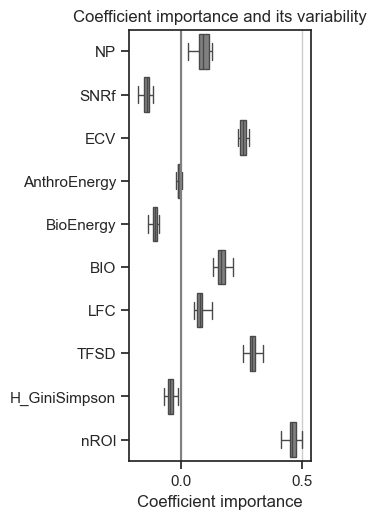

In [14]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(3,5)
fig.tight_layout()
ax.grid()
# sns.stripplot(data=df_coef, orient="h", palette="dark:k", alpha=0.25)
sns.boxplot(data=df_coef, orient="h", color="grey", saturation=0.1, whis=10)
# add grid
ax.axvline(x=0, color=".5")
plt.xlabel("Coefficient importance")
plt.title("Coefficient importance and its variability")
plt.subplots_adjust(left=0.3)


This extra code is to create the figure 1a and 1b of the manuscript which combines correlation (with bootstrap) and coefficent importance.

In [17]:
NOT_LIST_INDICES_MULTI_REG

[]

/home/haupert/miniconda3/envs/ear-ml/lib/python3.10/site-packages/matplotlib/cbook.py:1699: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return math.isfinite(val)
/home/haupert/miniconda3/envs/ear-ml/lib/python3.10/site-packages/matplotlib/cbook.py:1699: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return math.isfinite(val)


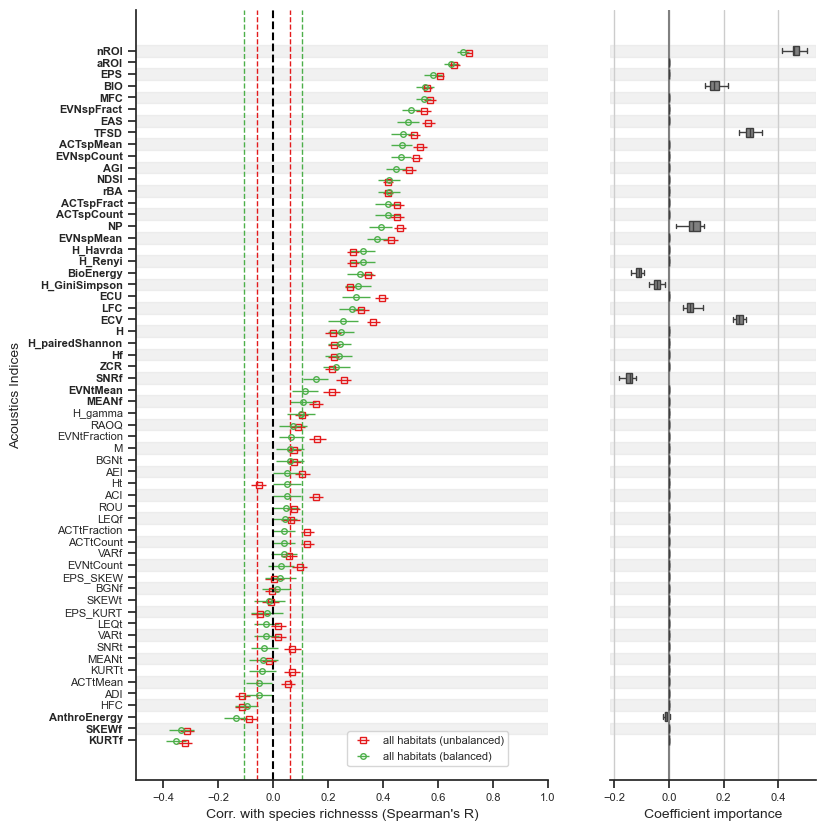

In [18]:
df_stat = pd.read_csv(os.path.join(CONFIG['save_dir'], GT+'_'+CONFIG['correlation_method']+"_r.csv"), sep=',', index_col=None)

# sort by r obtained with balanced dataset by habitats
sort_indices = df_stat[df_stat['habitat']=='all_balanced'].sort_values(by='r', ascending=False)['indice']

# Create an empty dictionary to store the mapping
indice_mapping = {}

# Iterate over the unique values of 'indice' and assign corresponding numbers
i = 0
for unique_indice in sort_indices:
    indice_mapping[unique_indice] = i
    i += 1

# Add the dictionary to the DataFrame
df_stat['indice_number'] = df_stat['indice'].map(indice_mapping)

# Generating labels and index
label = sort_indices
y = np.arange(len(label))

# select the indices with r > r_threshold for each habitat, dataset
df_all_balanced = df_stat[(df_stat['habitat']=='all_balanced')]
df_all_unbalanced = df_stat[(df_stat['habitat']=='all_unbalanced')]

# Apply the function to the 'list_column' and store the result in a new column
err_balanced = df_all_balanced['r'] - df_all_balanced['lower_bound_ci']
err_unbalanced =  df_all_unbalanced['r'] - df_all_unbalanced['lower_bound_ci']

sns.set_style("ticks")

# set 2 plots with shared y-axis but different size in x direction

fig, [ax1,ax2] = plt.subplots(1,2, width_ratios=(1,0.5), figsize=(8,10), sharey=True)

ax1.errorbar(x = df_all_unbalanced['r'], 
            y = df_all_unbalanced['indice_number'] + 0.2, 
            xerr=err_unbalanced, 
            label = 'all habitats (unbalanced)',
            marker='s', markersize = 4, markerfacecolor='none',
            linestyle="none", linewidth=1, color=RED, ecolor=RED)
ax1.errorbar(x = df_all_balanced['r'], 
            y = df_all_balanced['indice_number'] + 0.1, 
            xerr=err_balanced, 
            label = 'all habitats (balanced)',
            marker='o', markersize = 4, markerfacecolor='none',
            linestyle="none", linewidth=1, color=GREEN, ecolor=GREEN)

if format(CONFIG['correlation_method']) == 'pearson' :
    CORR_PLOT = 'Pearson'
elif format(CONFIG['correlation_method']) == 'spearman' :
    CORR_PLOT = 'Spearman'
elif format(CONFIG['correlation_method']) == 'kendall' :
    CORR_PLOT = 'Kendall'


ax1.set_xlabel('Corr. with species richnesss ({}\'s R)'.format(CORR_PLOT), fontsize=10)
ax1.set_ylabel('Acoustics Indices', fontsize=10)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax1.tick_params(axis='both', labelsize=8)

# Draw a vertical line at 0
ax1.axvline(x=0, color='black', linestyle='dashed')
ax1.axvline(x=df_stat[df_stat['habitat']=='all_unbalanced']['r_threshold'].unique(), color=RED, linestyle='dashed',linewidth=1)
ax1.axvline(x=df_stat[df_stat['habitat']=='all_balanced']['r_threshold'].unique(), color=GREEN, linestyle='dashed',linewidth=1)
ax1.axvline(x=-df_stat[df_stat['habitat']=='all_unbalanced']['r_threshold'].unique(), color=RED, linestyle='dashed',linewidth=1)
ax1.axvline(x=-df_stat[df_stat['habitat']=='all_balanced']['r_threshold'].unique(), color=GREEN, linestyle='dashed',linewidth=1)

# Reset y-ticks
ax1.set_yticks(y)
# Setting y-axis tick labels
ax1.set_yticklabels(label)

# Get axis labels on ax1
yticklabels = ax1.get_yticklabels()

# # Loop through labels and set font weight
for label in yticklabels:
    sub_df_stat = df_stat[df_stat['indice']==label.get_text()]

    # test if r is higher than r_threshold for habitat = 'all_balanced' and habitat = 'all_unbalanced'
    r_threshold_all_balanced = sub_df_stat[sub_df_stat['habitat'] == 'all_balanced']['r_threshold'].values[0]
    r_all_balanced = sub_df_stat[sub_df_stat['habitat'] == 'all_balanced']['r'].values[0]
    r_threshold_all_unbalanced = sub_df_stat[sub_df_stat['habitat'] == 'all_unbalanced']['r_threshold'].values[0]
    r_all_unbalanced = sub_df_stat[sub_df_stat['habitat'] == 'all_unbalanced']['r'].values[0]
    
    if ((abs(r_all_balanced)) > (abs(r_threshold_all_balanced))) and (abs((r_all_unbalanced)) > abs((r_threshold_all_unbalanced))) :
        label.set_fontweight('bold')

# Get the tick positions
y_ticks = ax1.get_yticks()
# Get the interval
y_delta = y_ticks[1] - y_ticks[0]
# Change background color every two ticks
for i in range(0, len(y_ticks), 2):
    ax1.axhspan(y_ticks[i]- y_delta/ 2, y_ticks[i] + y_delta/ 2, color='lightgrey', alpha=0.3)

# Set the x-axis limits
ax1.set_xlim(-0.5, 1)
# Create the legend and place it at the bottom of the figure
ax1.legend(loc='upper left', bbox_to_anchor=(0.5, 0.07), fontsize=8)

"""
    Second graph
"""

# Add the other indices to the dataframe df_coef and set the value to 0
NOT_LIST_INDICES_MULTI_REG = [col for col in df.columns if col not in LIST_INDICES_MULTI_REG]  
df_coef[NOT_LIST_INDICES_MULTI_REG] = 0
# order columns of df_coef following sort_indices
df_coef = df_coef[sort_indices]

# add grid
ax2.grid()
# sns.stripplot(data=df_coef, orient="h", palette="dark:k", alpha=0.25)
sns.boxplot(data=df_coef, orient="h", color="grey", saturation=0.1, whis=10, ax=ax2)
# add grid
ax2.axvline(x=0, color=".5")
# remove external lines around the graph
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
# change the size of the ticks
ax2.tick_params(axis='x', labelsize=8)

# Get the tick positions in y axis
y_ticks = ax2.get_yticks()
# Get the interval
y_delta = y_ticks[1] - y_ticks[0]
# Change background color every two ticks
for i in range(0, len(y_ticks), 2):
    ax2.axhspan(y_ticks[i]- y_delta/ 2, y_ticks[i] + y_delta/ 2, color='lightgrey', alpha=0.3)

# remove ticks on the vertical axis y on the axis ax2
ax2.tick_params(axis='y', color='white')

plt.xlabel("Coefficient importance", fontsize=10)
plt.subplots_adjust(left=0.05)

plt.show()


if SAVE : fig.savefig(os.path.join(CONFIG['save_dir'], 'figure_1a_b.png'), dpi = 300, bbox_inches = "tight")